In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as ticker

from chainconsumer import Chain, ChainConsumer, make_sample
from pathlib import Path

      cosmological_parameters--a_s  cosmological_parameters--omega_m  \
0                     5.586492e-09                          0.194475   
1                     3.840949e-09                          0.233166   
2                     4.587954e-09                          0.194107   
3                     2.949930e-09                          0.263934   
4                     1.368175e-09                          0.322881   
...                            ...                               ...   
4363                  3.688566e-09                          0.260727   
4364                  3.906962e-09                          0.218067   
4365                  5.805333e-09                          0.198462   
4366                  1.752219e-09                          0.375333   
4367                  2.445814e-09                          0.242522   

      cosmological_parameters--n_s  cosmological_parameters--h0  \
0                         1.004736                     0.705194   
1

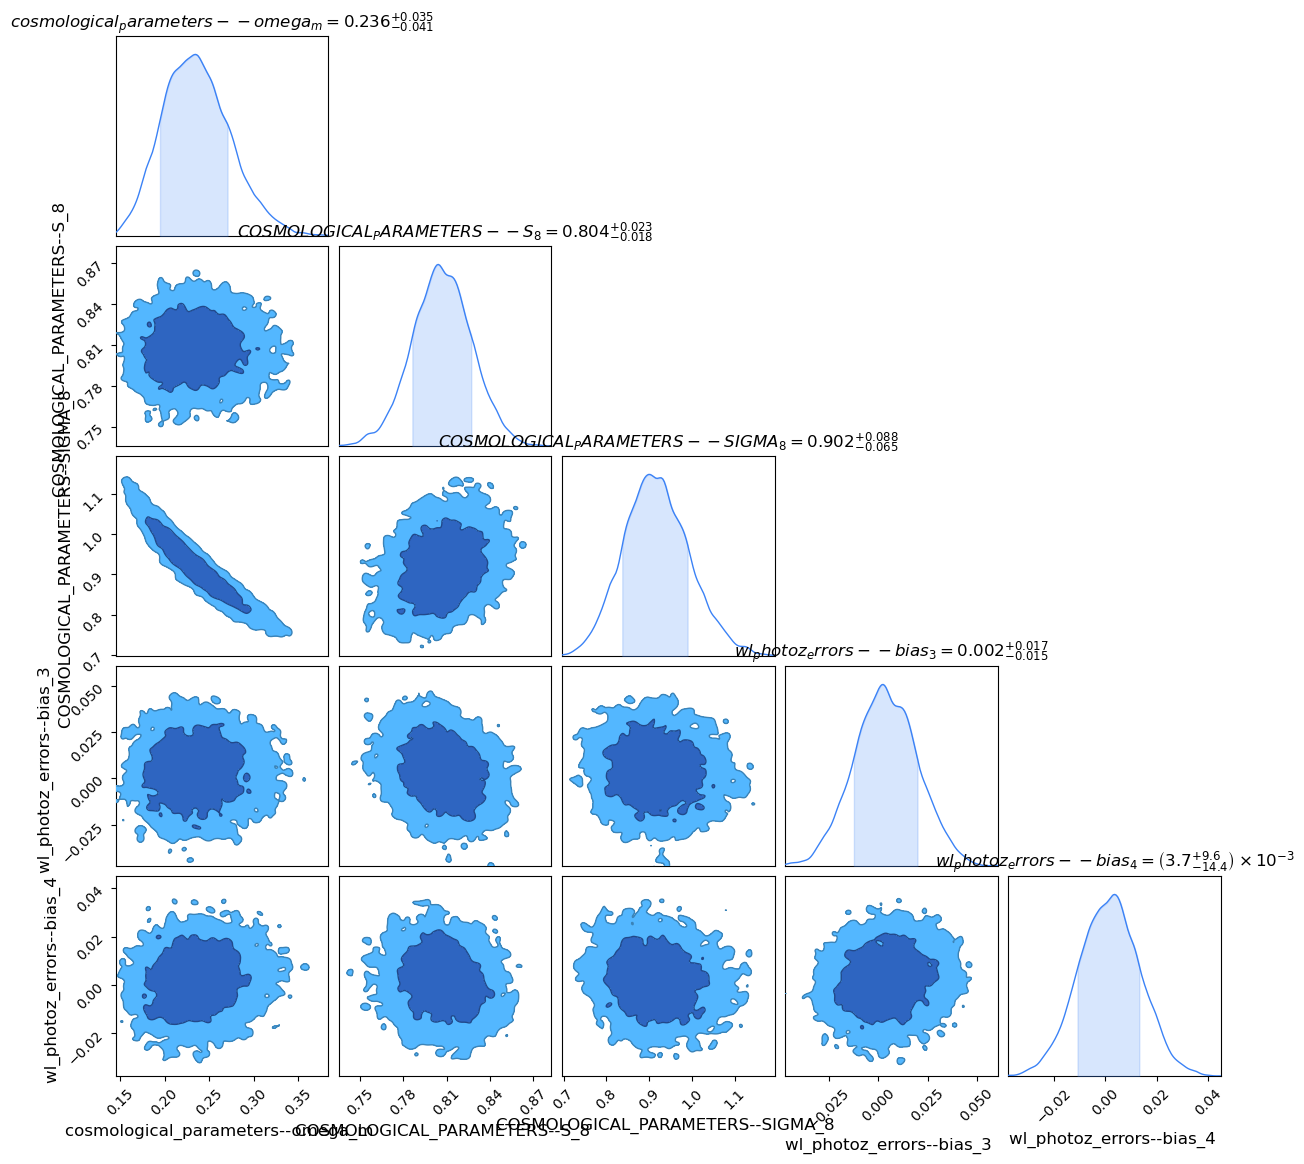

In [8]:
base_dir = Path("/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/cosmic_shear/chains")
ps_splines_file      = base_dir / "out-fourier/hsc-y3-shear.txt"
real_splines_file    = base_dir / "out-corrected-nz-real-10_10_25/hsc-y3-shear.txt"
ps_hscy3             = base_dir / "out-test-fourier/hsc-y3-shear.txt" 
ps_fid               = base_dir / "fiducial-hscy3-fourier/hsc_y3_fourier_cosmic_shear.txt"
real_fid             = base_dir / "fiducial-hscy3-real/polychord_fid.txt"

params = [
    "cosmological_parameters--omega_m",
    "COSMOLOGICAL_PARAMETERS--S_8",
    "COSMOLOGICAL_PARAMETERS--SIGMA_8",
    'wl_photoz_errors--bias_3',
    'wl_photoz_errors--bias_4'
]
param_labels = [r"\Omega_m", r"S_8", r"\sigma_8", r"\Delta z_3", r"\Delta z_4"]

def load_chain(filepath):
    """Load and process MCMC chain data"""
    with open(filepath, "r") as f:
        header = f.readline().lstrip("#").strip().split()

    df = pd.read_csv(
        filepath, 
        sep='\s+', 
        comment="#", 
        names=header
    )
    ## drop columns with NaN or inf values
    df = df.replace([np.inf, -np.inf], np.nan).dropna(axis=1)
    print(df)
    return df

df = load_chain(
    real_splines_file
)

c = ChainConsumer()
c.add_chain(Chain(samples=df, name="An Example Contour", weight_column='weight'))
fig = c.plotter.plot(columns=params)

In [2]:
### S8 constraints compared to other surveys
cmb_surveys = {
    
}

In [16]:
def load_and_process_data(filepath, new_priors=None, displace_mean_frompriors=None):
    """Load and process MCMC chain data"""
    with open(filepath, "r") as f:
        header = f.readline().lstrip("#").strip().split()

    df = pd.read_csv(
        filepath, 
        sep='\s+', 
        comment="#", 
        names=header
    )

    if new_priors is not None:
        assert "weight" in df.columns and all(name in df.columns for name in new_priors), "Weights column missing and some prior parameters not in data"
        weights = np.ones(len(df))
        for name in new_priors:
            assert name in df.columns, f'{name} not in columns'
            #old_prior_vals = old_priors[name].pdf(df[name])
            #new_prior_vals = new_priors[name].pdf(df[name])
            mu_i, sigma_i = new_priors[name]
            weights *= np.exp(-(df[name] - mu_i)**2 / (2 * sigma_i**2))
    else:
        weights = np.ones(len(df))
    
    if displace_mean_frompriors is not None:
        for name in displace_mean_frompriors:
            assert name in df.columns, f'{name} not in columns'
            mu_i, sigma_i = displace_mean_frompriors[name]
            current_mean = df[name].mean()
            print(current_mean, mu_i)
            df[name] += (mu_i - current_mean)

    return df, header, np.asarray(weights)

def compute_effective_weights(df, prior_rescale, use_log_weight=False):
    if use_log_weight:
        eff = np.exp(df["log_weight"].values) * prior_rescale
    else:
        eff = df["weight"].values * prior_rescale
    return eff

def make_mc_sample(df, params, param_labels, prior_rescale, label, burn=0.2, use_log_weight=False):
    print(f"Creating MCSamples for {label} with {len(df)} samples, burn={burn}, prior rescale={prior_rescale[:5]}")
    eff = compute_effective_weights(df, prior_rescale, use_log_weight)
    burn_count = int(np.floor(burn * len(df))) if burn>0 else 0
    samples = MCSamples(samples=df[params].values, names=params, labels=param_labels, weights=eff, label=label)
    samples.removeBurn(burn)

    df['post-reweighted'] = df['post'] + np.log(prior_rescale)
    return samples, df.iloc[burn_count:].reset_index(drop=True), eff[burn_count:]

def summarize_chain(samples: MCSamples, out_file: Path):
    """Compute LaTeX-friendly inline summary from MCSamples"""
    with open(out_file, 'a') as f:
        header = f"Summary for {samples.label}\n"
        f.write(header)
        print(header.strip())
        
        for param in samples.paramNames.list():
            line =  samples.getInlineLatex(param)
            f.write(f'{param}: {line}\n')
            print(line)
        f.write("\n")
        
def confidence_interval(x, cdf, level=0.68):
    """Return the lower and upper bounds of a central confidence interval."""
    lower_prob = (1 - level) / 2
    upper_prob = 1 - lower_prob
    lower = np.interp(x=lower_prob, xp=cdf, fp=x)
    upper = np.interp(x=upper_prob, xp=cdf, fp=x)
    return lower, upper

def summarize_samples(dfs_list, samples_list, params, filename, colors, linestyles):
    plt.figure(figsize=(12,4))
    plt.axhline(0, color='black', linestyle='--')
    with open(filename, "w") as f:
        for ins, (df, samples) in enumerate(zip(dfs_list, samples_list)):
            header = f"\n=== {samples.label} ===\n"
            print(header, end="")
            f.write(header)
            
            for p in params:
                max_idx = np.argmax(df["post-reweighted"].values)
                MAP_val = df[p].values[max_idx]
                
                param_density = samples.get1DDensity(p)
                x_sorted = param_density.x
                P_sorted = param_density.P
                prob = P_sorted / np.trapezoid(P_sorted, x_sorted)
                
                mode_idx = np.argmax(prob)
                posterior_mode = param_density.x[mode_idx]
                posterior_mean = np.trapezoid(prob * param_density.x, param_density.x)
                
                dx = np.mean(np.diff(x_sorted))
                param_cdf = np.cumsum(prob * dx) / np.sum(prob * dx)

                ci_68 = confidence_interval(param_density.x, param_cdf, 0.68)
                ci_95 = confidence_interval(param_density.x, param_cdf, 0.95)

                if p == "COSMOLOGICAL_PARAMETERS--S_8":
                    plt.plot(x_sorted, P_sorted, color=colors[ins], label=samples.label)
                    plt.axvline(posterior_mode, color=colors[ins], linestyle=linestyles[ins])
                    plt.axvline(ci_68[0], color=colors[ins], linestyle=linestyles[ins], alpha=0.5)
                    plt.axvline(ci_68[1], color=colors[ins], linestyle=linestyles[ins], alpha=0.5)
                    plt.legend(loc="upper right", fontsize=8)
                    plt.title(samples.label)
                    plt.grid()
                    plt.xlabel("S_8")
                    plt.ylabel("Density")
                    plt.xlim(0.65, 0.95)
                    
                line = (
                    f"{p:35s} | Mode: {posterior_mode:.4f}, "
                    f"MAP: {MAP_val:.4f}, "
                    f"Mean: {posterior_mean:.4f} "
                    f"68%-: {ci_68[0]:.4f}, 68%+: {ci_68[1]:.4f}, "
                    f"95%-: {ci_95[0]:.4f}, 95%+: {ci_95[1]:.4f}"
                )
                print(line)
                f.write(line + "\n")

-0.00035372580632403574 0.037
0.0017748602547459722 0.048
0.0038199150955405105 0.037
0.0016655236112098231 0.048


/tmp/ipykernel_540137/3140923890.py:49: RuntimeWarning: divide by zero encountered in log
  df['post-reweighted'] = df['post'] + np.log(prior_rescale)
/tmp/ipykernel_540137/3140923890.py:49: RuntimeWarning: divide by zero encountered in log
  df['post-reweighted'] = df['post'] + np.log(prior_rescale)


Creating MCSamples for New n(z) PS (pocoMC) with 4482 samples, burn=0.25, prior rescale=[1. 1. 1. 1. 1.]
Removed no burn in
Creating MCSamples for New n(z) Real (pocoMC) with 4368 samples, burn=0.25, prior rescale=[1. 1. 1. 1. 1.]
Removed no burn in
Creating MCSamples for HSC Y3 PS (pocoMC) with 2466 samples, burn=0.25, prior rescale=[1. 1. 1. 1. 1.]
Removed no burn in
Creating MCSamples for HSC Y3 PS (Fiducial) with 10496 samples, burn=0, prior rescale=[1. 1. 1. 1. 1.]
Removed no burn in
Creating MCSamples for HSC Y3 PS (Fiducial, reweighted) with 10496 samples, burn=0, prior rescale=[2.17080589e-043 0.00000000e+000 0.00000000e+000 9.95324680e-057
 9.86848459e-197]
Removed no burn in
Creating MCSamples for HSC Y3 Real (Fiducial) with 12598 samples, burn=0, prior rescale=[1. 1. 1. 1. 1.]
Removed no burn in
Creating MCSamples for HSC Y3 Real (Fiducial, reweighted) with 12598 samples, burn=0, prior rescale=[0.00000000e+000 0.00000000e+000 4.74653196e-101 1.61769591e-173
 0.00000000e+000]

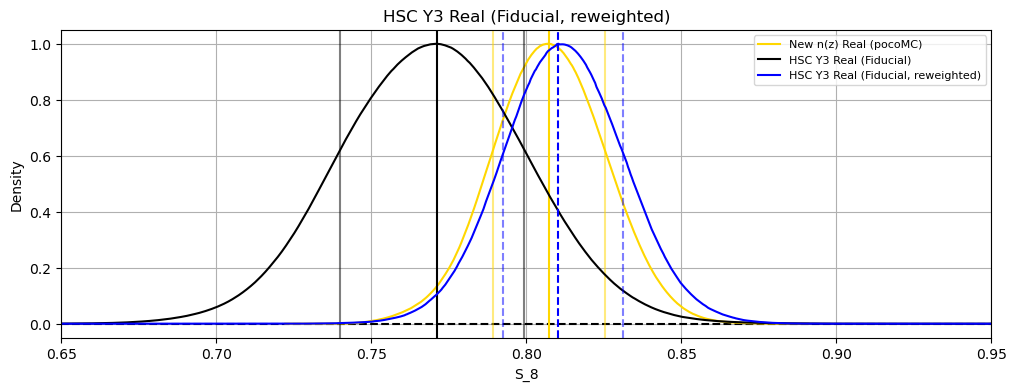

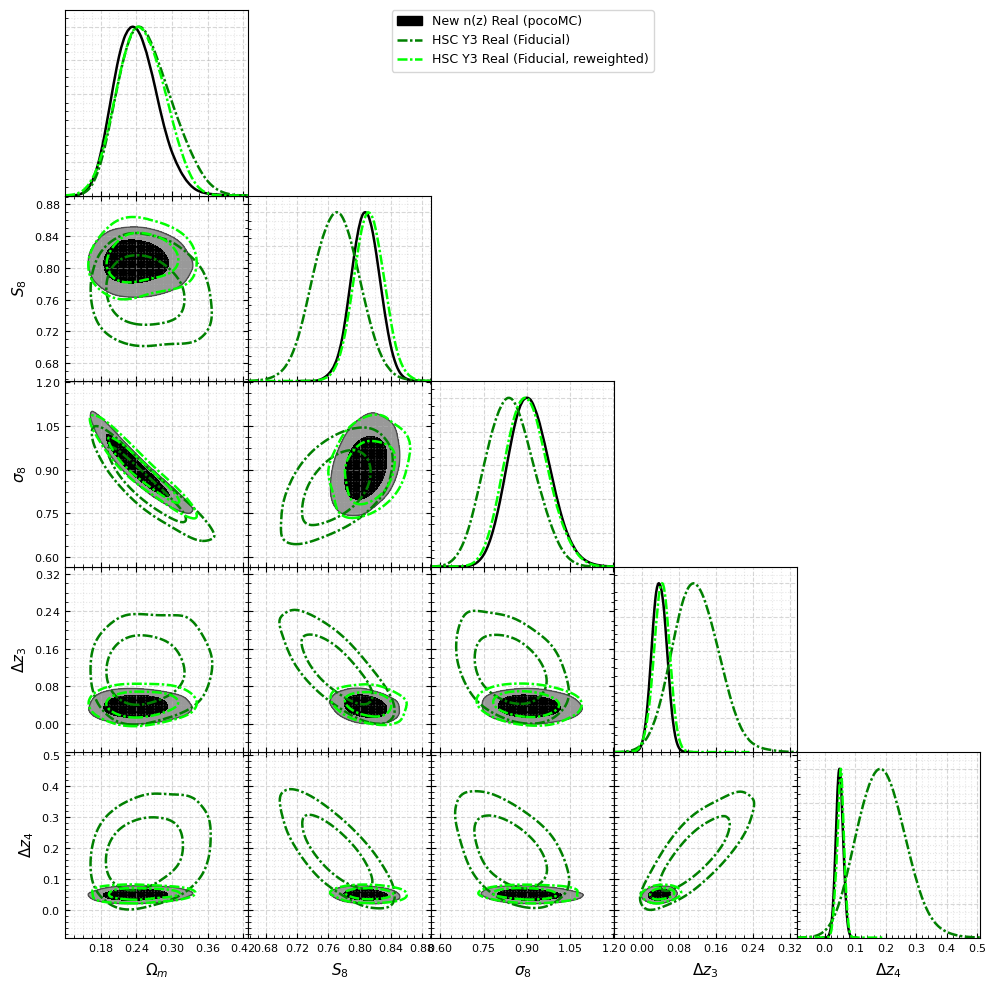

In [18]:
base_dir = Path("/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/cosmic-shear/chains")
ps_splines_file      = base_dir / "out-fourier/hsc-y3-shear.txt"
real_splines_file    = base_dir / "out-corrected-nz-real-10_10_25/hsc-y3-shear.txt"
ps_hscy3             = base_dir / "out-test-fourier/hsc-y3-shear.txt" 
ps_fid               = base_dir / "fiducial-hscy3-fourier/hsc_y3_fourier_cosmic_shear.txt"
real_fid             = base_dir / "fiducial-hscy3-real/polychord_fid.txt"

chain_files = [ps_splines_file, real_splines_file, ps_hscy3, ps_fid, ps_fid, real_fid, real_fid]
labels = [
    "New n(z) PS (pocoMC)", 
    "New n(z) Real (pocoMC)",
    "HSC Y3 PS (pocoMC)", 
    "HSC Y3 PS (Fiducial)",
    "HSC Y3 PS (Fiducial, reweighted)", 
    "HSC Y3 Real (Fiducial)", 
    "HSC Y3 Real (Fiducial, reweighted)",
]
priors = {
    #'wl_photoz_errors--bias_1': norm(loc=-0.026, scale=0.009),
    #'wl_photoz_errors--bias_2': norm(loc=-0.010, scale=0.007),
    'wl_photoz_errors--bias_3': (0.037, 0.021),
    'wl_photoz_errors--bias_4': (0.048, 0.012),
}
old_priors = {
    'wl_photoz_errors--bias_1': norm(0, scale=0.024),
    'wl_photoz_errors--bias_2': norm(0, scale=0.022),
    'wl_photoz_errors--bias_3': uniform(loc=-1, scale=2.0),
    'wl_photoz_errors--bias_4': uniform(loc=-1, scale=2.0),
}
params = [
    "cosmological_parameters--omega_m",
    "COSMOLOGICAL_PARAMETERS--S_8",
    "COSMOLOGICAL_PARAMETERS--SIGMA_8",
    #'wl_photoz_errors--bias_1',
    #'wl_photoz_errors--bias_2',
    #'halo_model_parameters--a_bary',
    'wl_photoz_errors--bias_3',
    'wl_photoz_errors--bias_4'
    #'halo_model_parameters--a_bary',
    #"intrinsic_alignment_parameters--a1",
    #"intrinsic_alignment_parameters--a2",
    #"intrinsic_alignment_parameters--alpha1",
    #"intrinsic_alignment_parameters--alpha2",
    #"intrinsic_alignment_parameters--bias_ta"
]
param_labels = [r"\Omega_m", r"S_8", r"\sigma_8", r"\Delta z_3", r"\Delta z_4"]
                #r"A_{bary}", r"A_{1}^{IA}", r"A_{2}^{IA}", r"\alpha_{1}^{IA}", r"\alpha_{2}^{IA}", r"b_{TA}^{IA}"]
base_burn = 0.25
priors_list = [None, None, None, None, priors, None, priors]
old_priors_list = [None, None, None, None, old_priors, None, old_priors]

df1, header1, prior_rescale1 = load_and_process_data(ps_splines_file, displace_mean_frompriors=priors)
df2, header2, prior_rescale2 = load_and_process_data(real_splines_file, displace_mean_frompriors=priors)
df3, header3, prior_rescale3 = load_and_process_data(ps_hscy3)
df4, header4, prior_rescale4 = load_and_process_data(ps_fid) 
df5, header5, prior_rescale5 = load_and_process_data(ps_fid, new_priors=priors)
df6, header6, prior_rescale6 = load_and_process_data(real_fid)
df7, header7, prior_rescale7 = load_and_process_data(real_fid, new_priors=priors)

samples1, ndf1, w1 = make_mc_sample(df1, params, param_labels, prior_rescale1, "New n(z) PS (pocoMC)", burn=base_burn, use_log_weight=True)
samples2, ndf2, w2 = make_mc_sample(df2, params, param_labels, prior_rescale2, "New n(z) Real (pocoMC)", burn=base_burn, use_log_weight=True)
samples3, ndf3, w3 = make_mc_sample(df3, params, param_labels, prior_rescale3, "HSC Y3 PS (pocoMC)", burn=base_burn, use_log_weight=True)
samples4, ndf4, w4 = make_mc_sample(df4, params, param_labels, prior_rescale4, "HSC Y3 PS (Fiducial)", burn=0)
samples5, ndf5, w5 = make_mc_sample(df5, params, param_labels, prior_rescale5, "HSC Y3 PS (Fiducial, reweighted)", burn=0)
samples6, ndf6, w6 = make_mc_sample(df6, params, param_labels, prior_rescale6, "HSC Y3 Real (Fiducial)", burn=0)
samples7, ndf7, w7 = make_mc_sample(df7, params, param_labels, prior_rescale7, "HSC Y3 Real (Fiducial, reweighted)", burn=0)

samples_list = [samples1, samples2, samples3, samples4, samples5, samples6, samples7]

colors = ["gold", "black", "blue", "cyan", "red", "green", "lime"]
linestyles = ["-", "-", "--", "--", "-", "-.", "-."]
filled = [True, True, False, False, False, False, False]

assert len(colors) == len(linestyles) == len(filled) == len(samples_list)
assert len(params) == len(param_labels)

out_summary = Path("summaries/summary.txt")
out_summary.parent.mkdir(exist_ok=True)
if out_summary.exists(): 
    out_summary.unlink() 
    
def do_mask(data, mask):
    return [d for d, m in zip(data, mask) if m]
mask = [False, True, False, False, False, True, True]
summarize_samples(
    dfs_list=do_mask([ndf1, ndf2, ndf3, ndf4, ndf5, ndf6, ndf7], mask),
    samples_list=do_mask([samples1, samples2, samples3, samples4, samples5, samples6, samples7], mask),
    params=params,
    filename=out_summary,
    colors=colors,
    linestyles=linestyles
)

print(f"\nPosterior summary also saved to {out_summary}")

g = gdplots.get_subplot_plotter()
g.triangle_plot(
    do_mask(samples_list, mask),
    params, 
    filled=do_mask(filled, mask),
    line_args=[{"color": c, "ls": ls, "lw": 1.8} for c, ls in zip(do_mask(colors, mask), do_mask(linestyles, mask))],
    contour_colors=do_mask(colors, mask), 
    contour_ls=do_mask(linestyles, mask), 
    contour_lws=[1.8]*np.sum(mask)
    )

for ax in g.subplots.flatten():
    if ax:
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=6))
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6))
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.grid(which='minor', linestyle=':', alpha=0.3)

plt.show()